In [1]:
import rioxarray as rix

In [2]:
example_tiff = r"../example_data/20241005bC0823515w353730n.tif"

In [3]:
helene_example = rix.open_rasterio(example_tiff)

In [4]:
helene_example

<xarray.DataArray (band: 3, y: 9415, x: 9415)> Size: 266MB
[265926675 values with dtype=uint8]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * y            (y) float64 75kB 35.63 35.63 35.63 35.63 ... 35.61 35.61 35.61
  * x            (x) float64 75kB -82.59 -82.59 -82.59 ... -82.57 -82.57 -82.57
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_DATETIME:        2024:10:05 23:59:59
    TIFFTAG_MINSAMPLEVALUE:  0
    TIFFTAG_MAXSAMPLEVALUE:  255
    AREA_OR_POINT:           Point
    scale_factor:            1.0
    add_offset:              0.0

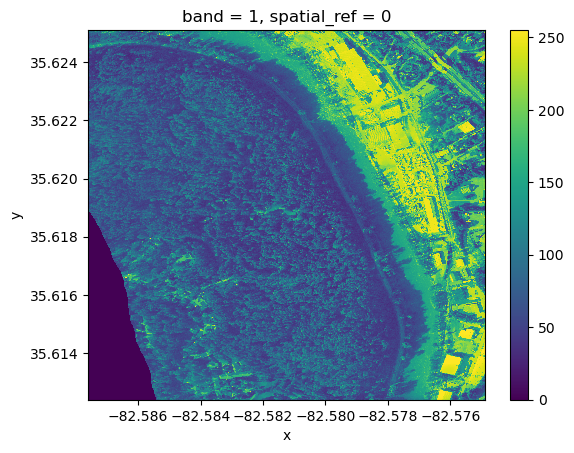

In [5]:
helene_example[0].plot()

In [6]:
import matplotlib.pyplot as plt

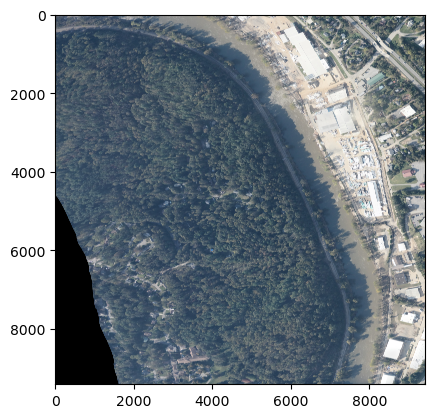

In [7]:
plt.imshow(helene_example.transpose('y', 'x', 'band').values)

In [8]:
from skimage.color import rgb2gray

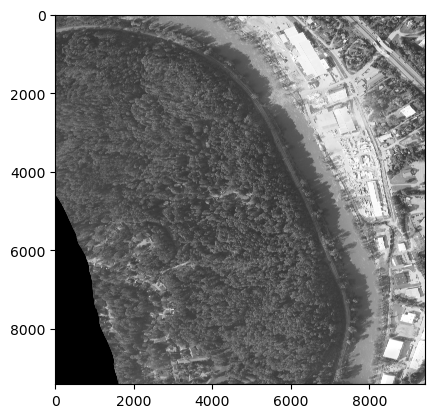

In [9]:
plt.imshow(rgb2gray(helene_example.transpose('y', 'x', 'band')), cmap=plt.cm.gray)

In [90]:
from skimage.filters.rank import entropy
from skimage.morphology import disk


c:\Users\sfreeman\Documents\408_508_public\uah_aes408_508_sp26_public\.pixi\envs\default\Lib\site-packages\IPython\core\interactiveshell.py:3701: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  exec(code_obj, self.user_global_ns, self.user_ns)


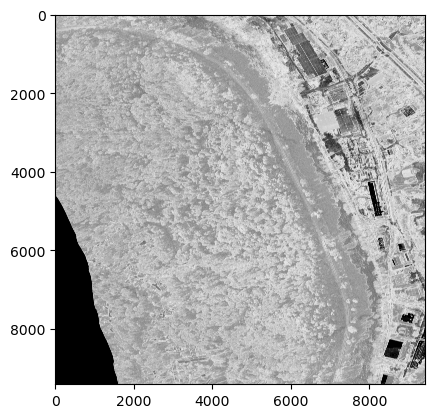

In [91]:
plt.imshow(entropy(rgb2gray(helene_example.transpose('y', 'x', 'band')), disk(5)), cmap=plt.cm.gray)

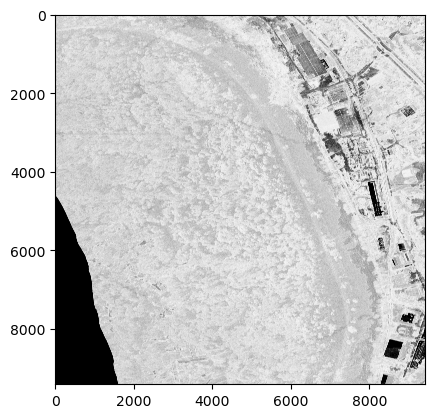

In [92]:
plt.imshow(entropy(rgb2gray(helene_example.transpose('y', 'x', 'band')), disk(2)), cmap=plt.cm.gray)

In [10]:
pre_storm_fn = r"C:\Users\sfreeman\Downloads\USDA_Pre_Storm-20260317T143521Z-1-001\USDA_Pre_Storm\m_3508228_nw_17_060_20220923.tif"

In [11]:
helene_prestorm = rix.open_rasterio(pre_storm_fn)

In [12]:
helene_prestorm

<xarray.DataArray (band: 4, y: 12380, x: 10300)> Size: 510MB
[510056000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 99kB 3.944e+06 3.944e+06 ... 3.936e+06 3.936e+06
  * x            (x) float64 82kB 3.525e+05 3.525e+05 ... 3.587e+05 3.587e+05
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

In [13]:
rgb_prestorm = helene_prestorm.sel(band=slice(1,3))

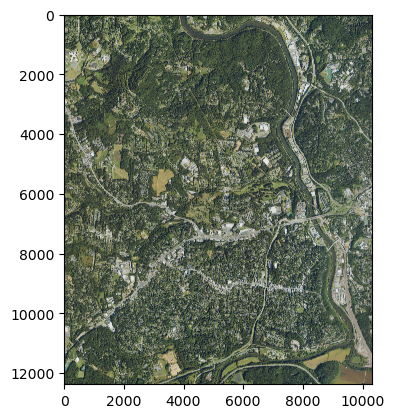

In [14]:
plt.imshow(rgb_prestorm.transpose('y', 'x', 'band'))

In [15]:
helene_example.rio.bounds()

(-82.5876, 35.6124, -82.57489999999999, 35.6251)

In [16]:
helene_example.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [17]:
prestorm_reproj = rgb_prestorm.rio.reproject(helene_example.rio.crs)

In [18]:
reproj_same_box = prestorm_reproj.rio.clip_box(*helene_example.rio.bounds())

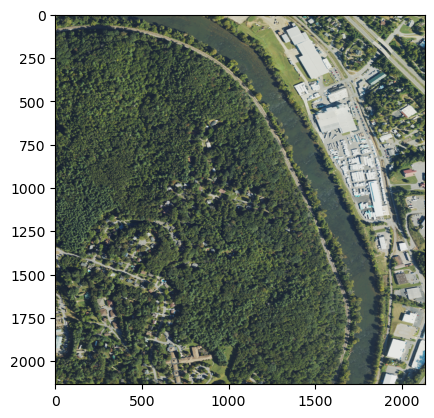

In [19]:
plt.imshow(reproj_same_box.transpose('y', 'x', 'band'))

In [20]:
from skimage.exposure import match_histograms


In [21]:
matched_post_storm = match_histograms(helene_example.values, reproj_same_box.values, channel_axis=0)


In [22]:
helene_example_matched = helene_example.copy()

In [23]:
helene_example_matched.values = matched_post_storm

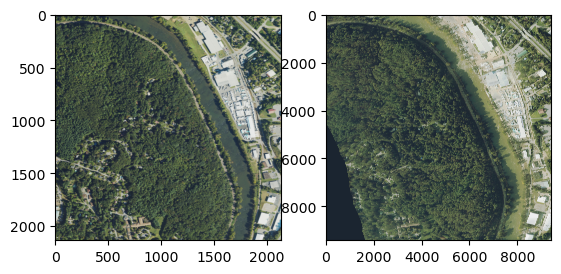

In [24]:
fig, axarr = plt.subplots(1,2)
axarr[0].imshow(reproj_same_box.transpose('y', 'x', 'band'))
axarr[1].imshow(helene_example_matched.transpose('y', 'x', 'band'))

In [29]:
from sklearn.cluster import kmeans_plusplus


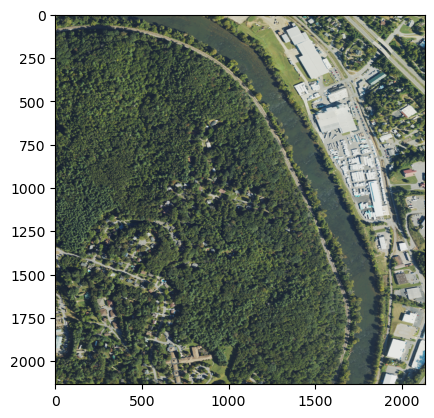

In [28]:
plt.imshow(reproj_same_box.transpose('y', 'x', 'band'))

In [53]:
sklearn_input = reproj_same_box.transpose('y', 'x', 'band').stack({'sample': ('y', 'x')}).transpose('sample', 'band')

In [54]:
import numpy as np

In [55]:
sklearn_input.values.astype(np.int32)

array([[ 27,  38,  55],
       [ 26,  38,  54],
       [ 27,  37,  54],
       ...,
       [148, 151, 100],
       [144, 145,  95],
       [137, 142,  96]], shape=(4551822, 3), dtype=int32)

In [57]:
import sklearn.cluster

In [59]:
fitted_data = sklearn.cluster.KMeans(n_clusters = 3).fit(sklearn_input.values.astype(np.int32))

In [61]:
fitted_data.labels_

array([2, 2, 2, ..., 0, 0, 0], shape=(4551822,), dtype=int32)

In [64]:
sklearn_output = sklearn_input.drop('band').copy()

C:\Users\sfreeman\AppData\Local\Temp\ipykernel_25784\4265780099.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  sklearn_output = sklearn_input.drop('band').copy()


In [77]:
fitted_data.labels_

array([2, 2, 2, ..., 0, 0, 0], shape=(4551822,), dtype=int32)

In [73]:
reproj_same_box.shape

(3, 2134, 2133)

In [78]:
np.unravel_index(fitted_data.labels_, reproj_same_box.shape[1:])

(array([0, 0, 0, ..., 0, 0, 0], shape=(4551822,)),
 array([2, 2, 2, ..., 0, 0, 0], shape=(4551822,)))

In [ ]:
fitted_data.labels_

In [56]:
kmeans_plusplus(sklearn_input.values.astype(np.int32), 3)

(array([[ 40,  49,  61],
        [150, 153, 106],
        [ 95, 115,  69]], dtype=int32),
 array([ 233511, 4105954, 1324650]))

In [25]:
axarr[1].imshow(helene_example_matched.transpose('y', 'x', 'band'))

In [26]:
helene_example_matched.band[0]

<xarray.DataArray 'band' ()> Size: 8B
array(1)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

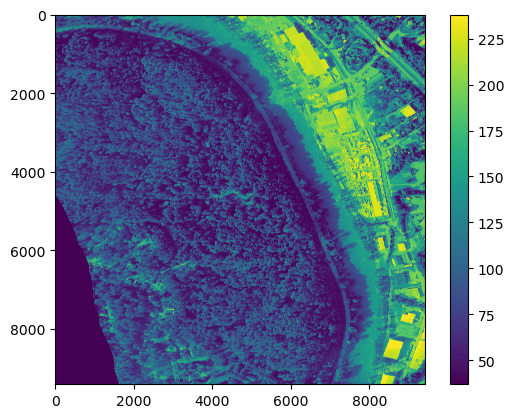

In [27]:
plt.imshow(helene_example_matched[1])
plt.colorbar()

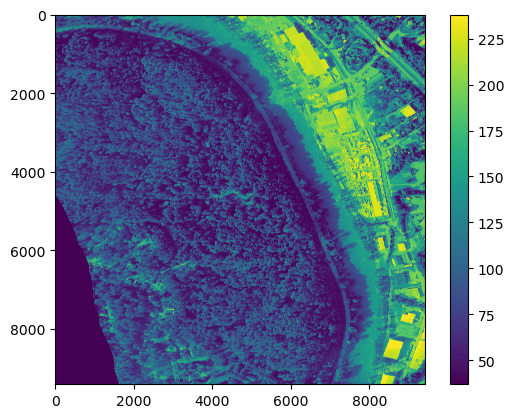

In [79]:
plt.imshow(helene_example_matched[1])
plt.colorbar()

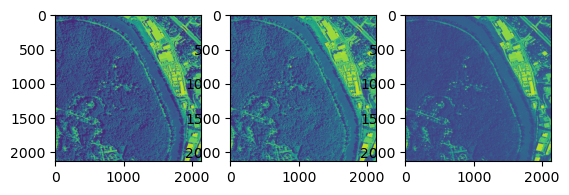

In [88]:
fig, axarr = plt.subplots(1,3)
axarr[0].imshow(reproj_same_box[0], vmin=0, vmax=255)
axarr[1].imshow(reproj_same_box[1], vmin=0, vmax=255)
axarr[2].imshow(reproj_same_box[2], vmin=0, vmax=255)
#plt.colorbar()

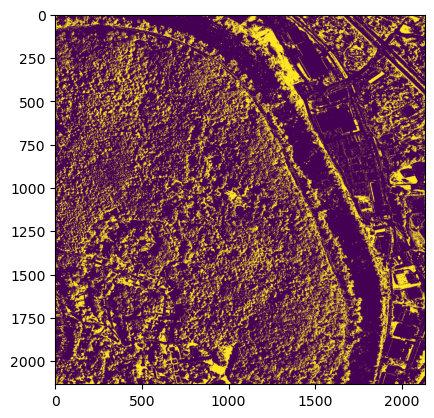

In [89]:
plt.imshow(np.logical_and(reproj_same_box[0]<150, reproj_same_box[1]>100))

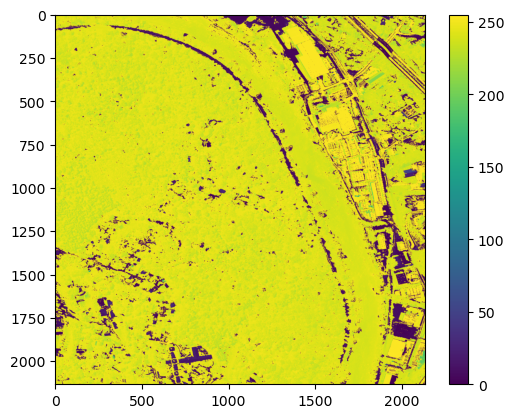

In [86]:
plt.imshow(reproj_same_box[0]-reproj_same_box[1])
#axarr[1].imshow(reproj_same_box[1])
plt.colorbar()